In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import seaborn as sns
import pingouin as pg

from nilearn import plotting
from nilearn.image import new_img_like

In [2]:
import rsatoolbox
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed, Model
from rsatoolbox.rdm import RDMs
from rsatoolbox.vis import show_rdm, show_rdm_panel

from glob import glob

In [3]:
from scipy import stats

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp, ttest_rel

In [60]:
import sys
sys.path.insert(0, '..')   # or wherever stats_fmt.py lives relative to the notebook
from stats_fmt import fmt_t, fmt_F, fmt_p, fmt_r, stat_str, fmt_pingouin_anova


In [4]:
# print stats as human-readable
pd.set_option('display.float_format', '{:.4f}'.format)

In [5]:
def upper_tri(RDM):
    """upper_tri returns the upper triangular index of an RDM

    Args:
        RDM 2Darray: squareform RDM

    Returns:
        1D array: upper triangular vector of the RDM
    """
    # returns the upper triangle
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

In [6]:
project_dir = os.path.join('/ix1/bchandrasekaran/krs228/data/', 'FLT/')
fmriprep_dir = os.path.join(project_dir, 'data_denoised/derivatives/',
                            'denoised_fmriprep-22.1.1/')

bidsroot = os.path.join(project_dir, 'data_denoised')
deriv_dir = os.path.join(bidsroot, 'derivatives')

fwhm_sub = 0
model_dir = os.path.join(deriv_dir, 'nilearn', f'bids-deriv_level-1_fwhm-{fwhm_sub:.02f}')

task_list = ['tonecat']
space_label = 'MNI152NLin2009cAsym'

In [7]:
statmap = 't' # 'beta', 'tstat'

In [8]:
model_desc = 'per_run_LSS_confound-compcor_event-stimulus' # 'grouped-runs_LSS_event-stimulus' 'per_run_LSA_confound-compcor_event-stimulus'

In [9]:
model_dir

'/ix1/bchandrasekaran/krs228/data/FLT/data_denoised/derivatives/nilearn/bids-deriv_level-1_fwhm-0.00'

## Load behavioral accuracy outputs for brain-behavior correlations

In [10]:
beh_out_dir = os.path.join(bidsroot, 'derivatives', 'behavior')
acc_df = pd.read_csv(os.path.join(beh_out_dir, 'run_accuracies.tsv'), sep='\t')

In [11]:
acc_df.sort_values(by=['participant_id', 'run'], inplace=True)
acc_df.head(10)

,participant_id,run,accuracy
78,sub-FLT02,run-01,0.4028
79,sub-FLT02,run-02,0.8636
80,sub-FLT02,run-03,0.8500
81,sub-FLT02,run-04,0.8250
82,sub-FLT02,run-05,0.9129
83,sub-FLT02,run-06,0.8958
0,sub-FLT03,run-01,0.9792
1,sub-FLT03,run-02,1.0000
2,sub-FLT03,run-03,0.9792
3,sub-FLT03,run-04,1.0000


mean accuracy = 0.7959


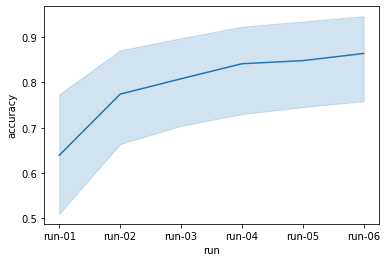

In [12]:
print(f'mean accuracy = {acc_df.accuracy.mean():.04f}')
sns.lineplot(acc_df, x='run', y='accuracy');

## Make categorical models

In [13]:
pattern_descriptors = {'tone': ['T1', 'T1', 'T1', 'T1', 
                                'T2', 'T2', 'T2', 'T2', 
                                'T3', 'T3', 'T3', 'T3', 
                                'T4', 'T4', 'T4', 'T4', ],
                       'talker': ['M1', 'M2', 'F1', 'F2',
                                  'M1', 'M2', 'F1', 'F2',
                                  'M1', 'M2', 'F1', 'F2',
                                  'M1', 'M2', 'F1', 'F2', ],
                      }
                                  

### Categorical RDMs

In [14]:
# make categorical RDMs
tone_rdm = np.array([[0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,],
                     [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,], ])

talker_rdm = np.array([[0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ],
                       [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ],
                       [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ],
                       [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, ],
                       [1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, ],
                       [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, ],
                       [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, ], ])

rdms_array = np.array([tone_rdm, talker_rdm])

In [15]:
cat_rdms = RDMs(rdms_array,
                  rdm_descriptors={'categorical_model':['tone', 'talker'],},
                  pattern_descriptors=pattern_descriptors,
                  dissimilarity_measure='Euclidean'
                 )

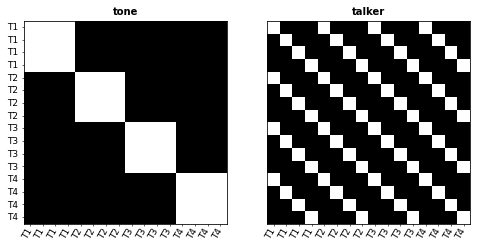

In [16]:
fig = show_rdm(cat_rdms, 
               rdm_descriptor='categorical_model', 
               pattern_descriptor='tone', 
               figsize=(8,4),)

#### Convert from RDM to Model

In [17]:
tone_model = ModelFixed( 'Tone RDM', cat_rdms.subset('categorical_model', 'tone'))
talker_model = ModelFixed( 'Talker RDM', cat_rdms.subset('categorical_model', 'talker'))
cat_models = [tone_model, talker_model]

## Set up participants

In [18]:
participants_fpath = os.path.join(bidsroot, 'participants.tsv')
participants_df = pd.read_csv(participants_fpath, sep='\t')

# subjects to ignore (not fully processed, etc.)
ignore_subs = ['sub-FLT27', # always leave out FLT27 – did not participate
               'sub-FLT07', # bad QA 11/14/23 
              ]
participants_df.drop(participants_df[participants_df.participant_id.isin(ignore_subs)].index,
                     inplace=True)

# re-sort by participant ID
participants_df.sort_values(by=['participant_id'], 
                            ignore_index=True, 
                            inplace=True)

In [19]:
participants_df

,participant_id,age,sex,group,FFR_id
0,sub-FLT02,21,F,non-Mandarin,1002.0000
1,sub-FLT03,25,F,Mandarin,2002.0000
2,sub-FLT04,21,F,non-Mandarin,1003.0000
3,sub-FLT05,26,M,Mandarin,3010.0000
4,sub-FLT06,21,F,non-Mandarin,3001.0000
5,sub-FLT08,23,F,Mandarin,2005.0000
6,sub-FLT09,30,F,non-Mandarin,3002.0000
7,sub-FLT10,23,F,Mandarin,2006.0000
8,sub-FLT11,20,F,non-Mandarin,1005.0000
9,sub-FLT12,20,F,non-Mandarin,3004.0000


In [20]:
# create group-specific lists of subject IDs
sub_group_dict = {'Mandarin': list(participants_df.participant_id[participants_df.group=='Mandarin']),
                  'non-Mandarin': list(participants_df.participant_id[participants_df.group=='non-Mandarin'])}

In [21]:
sub_group_dict

{'Mandarin': ['sub-FLT03',
  'sub-FLT05',
  'sub-FLT08',
  'sub-FLT10',
  'sub-FLT15',
  'sub-FLT17',
  'sub-FLT18',
  'sub-FLT19',
  'sub-FLT21',
  'sub-FLT22',
  'sub-FLT23',
  'sub-FLT24',
  'sub-FLT26'],
 'non-Mandarin': ['sub-FLT02',
  'sub-FLT04',
  'sub-FLT06',
  'sub-FLT09',
  'sub-FLT11',
  'sub-FLT12',
  'sub-FLT13',
  'sub-FLT14',
  'sub-FLT20',
  'sub-FLT25',
  'sub-FLT28',
  'sub-FLT30']}

In [22]:
participant_list = participants_df.participant_id
participant_list = [p.split('-')[1] for p in participant_list]
group_assignment = participants_df.group

# Run with striatal ROIs

## Define network ROIs

In [23]:
## define ROIs
network_name = 'tian_subcortical_S2' # 'tian_subcortical_S3', 'tian_subcortical_S2', 'auditory'

if network_name == 'auditory':
    roi_list_ordered = [
                'L-IC', 'L-MGN', 'L-HG', 'L-PT',  'L-PP', 'L-STGp', 'L-STGa', 'L-ParsOp', 'L-ParsTri',
                'R-IC', 'R-MGN', 'R-HG', 'R-PT',  'R-PP', 'R-STGp', 'R-STGa', 'R-ParsOp', 'R-ParsTri', 
               ]
elif network_name == 'aud-striatal':
    roi_list_ordered = ['L-Caud', 'L-Put', 'L-IC', 'L-MGN',
                'L-HG', 'L-PP', 'L-PT', 'L-STGa', 'L-STGp', 
                'L-ParsOp', 'L-ParsTri',
                'R-Caud', 'R-Put','R-IC', 'R-MGN',
                'R-HG', 'R-PP', 'R-PT', 'R-STGa', 'R-STGp', 
                'R-ParsOp', 'R-ParsTri',
               ]
elif network_name == 'tian_subcortical_S3':
    roi_list_ordered = [
        'CAU-DA-lh', 'CAU-DA-rh', 
        'CAU-VA-lh', 'CAU-VA-rh', 
        'pCAU-lh', 'pCAU-rh', 
        'PUT-DA-lh', 'PUT-DA-rh', 
        'PUT-DP-lh', 'PUT-DP-rh', 
        'PUT-VA-lh', 'PUT-VA-rh', 
        'PUT-VP-lh', 'PUT-VP-rh',
        'NAc-core-lh',  'NAc-core-rh', 
        'NAc-shell-lh', 'NAc-shell-rh', 
         #'aGP-lh', 'pGP-lh', 
         #'aGP-rh', 'pGP-rh',         
               ]
elif network_name == 'tian_subcortical_S2':
    roi_list_ordered = [
                    #'pGP-rh', 'pGP-lh',
                    #'aGP-rh', 'aGP-lh',
                    'aCAU-lh',
                    'pCAU-lh',
                    'aPUT-lh',
                    'pPUT-lh',
                    #'NAc-shell-lh',
                    #'NAc-core-lh',
                    'aCAU-rh',
                    'pCAU-rh',
                    'aPUT-rh',
                    'pPUT-rh',
                    #'NAc-shell-rh',
                    #'NAc-core-rh',
                    ]


## Load run-specific subject-specific RDMs

In [24]:
# from `rsa_roi.py`-generated outputs
group_rdm_list = []
for sx, sub_id in enumerate(participant_list): # enumerate(['FLT03']): #
    print(sub_id)
    group_id = group_assignment[sx]

    out_dir = os.path.join(model_dir, f'rsa_roi_{model_desc}', 
                           'run-grouped', network_name)
    sub_fpath = os.path.join(out_dir,
                         f'sub-{sub_id}_run-grouped_{network_name}_{model_desc}_rdms.hdf5')
    sub_rdm = rsatoolbox.rdm.rdms.load_rdm(sub_fpath)
    
    # add the group descriptor to the subject's RDM
    sub_rdm.rdm_descriptors['group'] = [group_id for x in sub_rdm.rdm_descriptors['index']]
    group_rdm_list.append(sub_rdm)
group_rdms = rsatoolbox.rdm.rdms.concat(group_rdm_list)

FLT02
FLT03
FLT04
FLT05
FLT06
FLT08
FLT09
FLT10
FLT11
FLT12
FLT13
FLT14
FLT15
FLT17
FLT18
FLT19
FLT20
FLT21
FLT22
FLT23
FLT24
FLT25
FLT26
FLT28
FLT30


In [25]:
results = rsatoolbox.inference.eval_fixed(cat_models,
                                          group_rdms.subset('group', 'non-Mandarin'),
                                          method='corr')
print(results)

Results for running fixed evaluation for corr on 2 models:

Model      |   Eval ± SEM   | p (against 0) | p (against NC) |
--------------------------------------------------------------
Tone RDM   |  0.006 ± 0.003 |        0.032  |       < 0.001  |
Talker RDM | -0.013 ± 0.003 |        1.000  |       < 0.001  |

p-values are based on uncorrected t-tests


<Axes: ylabel='Count'>

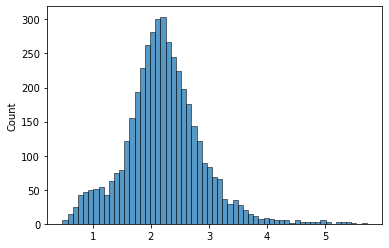

In [26]:
sns.histplot(sub_rdm.dissimilarities.flatten())

(<Figure size 900x720 with 2 Axes>, <Axes: >, <Axes: >)

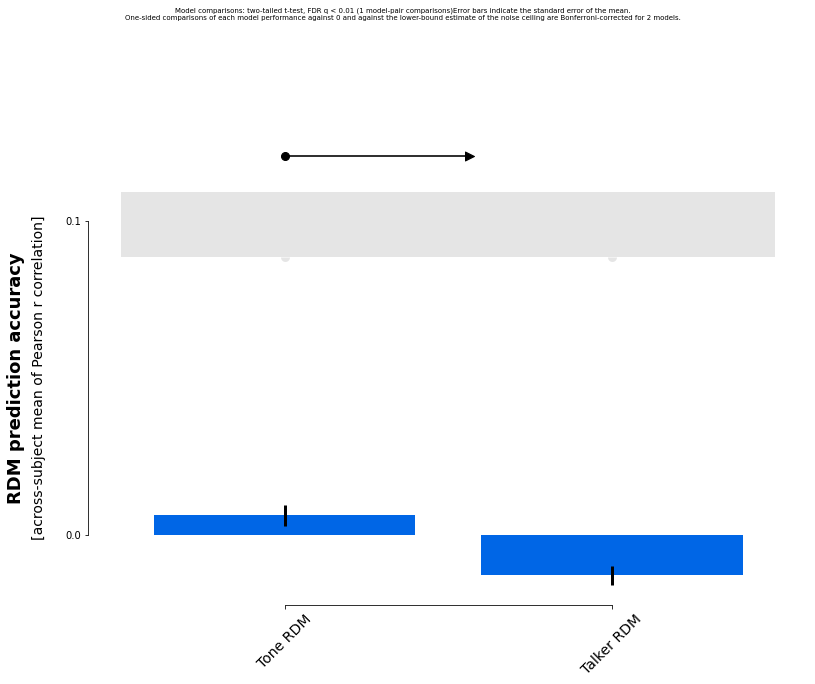

In [27]:
rsatoolbox.vis.plot_model_comparison(results)

### Per "stage" (runcombo), per subject

In [28]:
runcombo_dict = {'early': ['run00', 'run01'], 
                 'middle': ['run02', 'run03'], 
                 'final': ['run04','run05']}

'''
runcombo_dict = {'early': ['run00', 'run01', 'run02'], 
                 'final': ['run03', 'run04', 'run05']}
'''


"\nruncombo_dict = {'early': ['run00', 'run01', 'run02'], \n                 'final': ['run03', 'run04', 'run05']}\n"

### Participant-specific across-model comparisons

In [29]:
group_dict = {}

for group_id in ['non-Mandarin']: #np.unique(group_rdms.rdm_descriptors['group']):

    for full_sub_id in sub_group_dict[group_id]:
        sub_id = full_sub_id[4:]

        sub_rdm_subset = group_rdms.subset('participant', value=sub_id)
        sub_dict = {}

        for rungroup in runcombo_dict:
            # initialize results list
            runcombo_roi_res_dict = {}
            
            for ROI in roi_list_ordered:
                print(f'{sub_id} runcombo-{rungroup} ROI-{ROI}')

                rdm_subset = sub_rdm_subset.subset('rungroup', value=rungroup).subset('ROI',value=ROI)
                results_grr = rsatoolbox.inference.eval_fixed(cat_models,
                                                              rdm_subset,  
                                                              method='corr',
                                                             )
                runcombo_roi_res_dict[ROI] = results_grr.get_means()#[0]

            sub_dict[rungroup] = runcombo_roi_res_dict

        group_dict[sub_id] = sub_dict

FLT02 runcombo-early ROI-aCAU-lh
FLT02 runcombo-early ROI-pCAU-lh
FLT02 runcombo-early ROI-aPUT-lh
FLT02 runcombo-early ROI-pPUT-lh
FLT02 runcombo-early ROI-aCAU-rh
FLT02 runcombo-early ROI-pCAU-rh
FLT02 runcombo-early ROI-aPUT-rh
FLT02 runcombo-early ROI-pPUT-rh
FLT02 runcombo-middle ROI-aCAU-lh
FLT02 runcombo-middle ROI-pCAU-lh
FLT02 runcombo-middle ROI-aPUT-lh
FLT02 runcombo-middle ROI-pPUT-lh
FLT02 runcombo-middle ROI-aCAU-rh
FLT02 runcombo-middle ROI-pCAU-rh
FLT02 runcombo-middle ROI-aPUT-rh
FLT02 runcombo-middle ROI-pPUT-rh
FLT02 runcombo-final ROI-aCAU-lh
FLT02 runcombo-final ROI-pCAU-lh
FLT02 runcombo-final ROI-aPUT-lh
FLT02 runcombo-final ROI-pPUT-lh
FLT02 runcombo-final ROI-aCAU-rh
FLT02 runcombo-final ROI-pCAU-rh
FLT02 runcombo-final ROI-aPUT-rh
FLT02 runcombo-final ROI-pPUT-rh
FLT04 runcombo-early ROI-aCAU-lh
FLT04 runcombo-early ROI-pCAU-lh
FLT04 runcombo-early ROI-aPUT-lh
FLT04 runcombo-early ROI-pPUT-lh
FLT04 runcombo-early ROI-aCAU-rh
FLT04 runcombo-early ROI-pCAU-rh
FL

In [30]:
print(results_grr)

Results for running fixed evaluation for corr on 2 models:

Model      |   Eval ± SEM   | p (against 0) | p (against NC) |
--------------------------------------------------------------
Tone RDM   | -0.028 ±  nan |          nan  |           nan  |
Talker RDM | -0.090 ±  nan |          nan  |           nan  |

p-values are based on uncorrected t-tests


In [28]:
#rsatoolbox.vis.plot_model_comparison(results_grr)

#### Make dataframe

In [31]:
group_df_list = []
for group_id in ['non-Mandarin']: #np.unique(group_rdms.rdm_descriptors['group']):
    print(group_id)
    sub_df_list = []
    
    for full_sub_id in sub_group_dict[group_id]:
        try:
            sub_id = full_sub_id[4:]

            sub_df = pd.DataFrame.from_dict(group_dict[sub_id])
            sub_df['sub_id'] = sub_id
            sub_df_list.append(sub_df)
        except KeyError:
            print(f'not available for {full_sub_id}')

    group_df = pd.concat(sub_df_list)
    group_df.reset_index(inplace=True)
    long_group_df = group_df.melt(#value_vars=['earlythird','latethird'],#['early','final'], 
                                  value_vars=['early','middle','final'],  # 'middle',
                                  id_vars=['index', 'sub_id'], 
                                  value_name='similarity', 
                                  var_name='learning_stage', 
                                  ignore_index=False)
    long_group_df['participant_group'] = group_id
    long_group_df.rename(columns={"index": "ROI"}, inplace=True)
    long_group_df.rename(columns={"sub_id": "participant_id"}, inplace=True)
    
    group_df_list.append(long_group_df)

long_df = pd.concat(group_df_list)

non-Mandarin


In [32]:
# get model names for the models in the RSA operation
model_names = [x.name for x in results_grr.models]
print(model_names)

['Tone RDM', 'Talker RDM']


In [33]:
# split the results arrays into single-element columns by model
long_df[model_names] = long_df['similarity'].to_list()
long_df.drop('similarity', axis='columns', inplace=True) 

In [34]:
# reshape the dataframe again
model_long_df = long_df.melt(value_vars=model_names, 
                             id_vars=['ROI', 'learning_stage', 'participant_id', 'participant_group'], 
                             value_name='similarity', 
                             var_name='model', 
                             ignore_index=False)
model_long_df.reset_index(inplace=True)

# get rid of "middle" stage
#model_long_df.drop(model_long_df[model_long_df.learning_stage=='middle'].index, inplace=True)

In [35]:
model_long_df.head()

,index,ROI,learning_stage,participant_id,participant_group,model,similarity
0,0,aCAU-lh,early,FLT02,non-Mandarin,Tone RDM,0.0465
1,1,pCAU-lh,early,FLT02,non-Mandarin,Tone RDM,0.0401
2,2,aPUT-lh,early,FLT02,non-Mandarin,Tone RDM,0.0607
3,3,pPUT-lh,early,FLT02,non-Mandarin,Tone RDM,0.1060
4,4,aCAU-rh,early,FLT02,non-Mandarin,Tone RDM,-0.0462


#### Move hemisphere to separate column

In [36]:
laterality_df = model_long_df.copy()
laterality_df['hemisphere'] = laterality_df['ROI'].str[-2:]
laterality_df['ROI_hemi'] = laterality_df['ROI']
laterality_df['ROI'] = laterality_df['ROI'].str[:-3]

In [37]:
laterality_df.head()

,index,ROI,learning_stage,participant_id,participant_group,model,similarity,hemisphere,ROI_hemi
0,0,aCAU,early,FLT02,non-Mandarin,Tone RDM,0.0465,lh,aCAU-lh
1,1,pCAU,early,FLT02,non-Mandarin,Tone RDM,0.0401,lh,pCAU-lh
2,2,aPUT,early,FLT02,non-Mandarin,Tone RDM,0.0607,lh,aPUT-lh
3,3,pPUT,early,FLT02,non-Mandarin,Tone RDM,0.1060,lh,pPUT-lh
4,4,aCAU,early,FLT02,non-Mandarin,Tone RDM,-0.0462,rh,aCAU-rh


#### Move subdivision to separate column

In [38]:
striatal_df = laterality_df.copy()
split_df = striatal_df['ROI'].str.split('-', expand=True)
split_df.columns = ['region']
split_df.loc[split_df.region.str.startswith('p'),'subdivision'] = 'post'
split_df.loc[split_df.region.str.startswith('a'),'subdivision'] = 'ant'
striatal_df = striatal_df.join(split_df)
striatal_df.head()

,index,ROI,learning_stage,participant_id,participant_group,model,similarity,hemisphere,ROI_hemi,region,subdivision
0,0,aCAU,early,FLT02,non-Mandarin,Tone RDM,0.0465,lh,aCAU-lh,aCAU,ant
1,1,pCAU,early,FLT02,non-Mandarin,Tone RDM,0.0401,lh,pCAU-lh,pCAU,post
2,2,aPUT,early,FLT02,non-Mandarin,Tone RDM,0.0607,lh,aPUT-lh,aPUT,ant
3,3,pPUT,early,FLT02,non-Mandarin,Tone RDM,0.1060,lh,pPUT-lh,pPUT,post
4,4,aCAU,early,FLT02,non-Mandarin,Tone RDM,-0.0462,rh,aCAU-rh,aCAU,ant


In [39]:
split_df

,region,subdivision
0,aCAU,ant
1,pCAU,post
2,aPUT,ant
3,pPUT,post
4,aCAU,ant
...,...,...
571,pPUT,post
572,aCAU,ant
573,pCAU,post
574,aPUT,ant


#### Make rostral/caudal columnjoin

In [40]:
rostcaud_df = striatal_df.copy()

# create a new column based on rostral–caudal axis
rostcaud_df['Axis'] = ''


if network_name == 'tian_subcortical_S3':
    rostcaud_df.loc[(striatal_df['region']=='pCAU'),   'Axis'] = 'Caudal'
    rostcaud_df.loc[(striatal_df['region']=='PUT-VP'), 'Axis'] = 'Caudal'
    rostcaud_df.loc[(striatal_df['region']=='PUT-DP'), 'Axis'] = 'Caudal'

    rostcaud_df.loc[striatal_df['region']=='CAU-DA', 'Axis'] = 'Rostral'
    rostcaud_df.loc[striatal_df['region']=='CAU-VA', 'Axis'] = 'Rostral'
    rostcaud_df.loc[striatal_df['region']=='CAU-DP', 'Axis'] = 'Rostral'
    rostcaud_df.loc[striatal_df['region']=='CAU-VP', 'Axis'] = 'Rostral'

    rostcaud_df.loc[striatal_df['region']=='PUT-VA', 'Axis'] = 'Rostral'
    rostcaud_df.loc[striatal_df['region']=='PUT-DA', 'Axis'] = 'Rostral'

    rostcaud_df.loc[striatal_df['region']=='NAc-shell', 'Axis'] = 'Ventral'
    rostcaud_df.loc[striatal_df['region']=='NAc-core', 'Axis'] = 'Ventral'

elif network_name == 'tian_subcortical_S2':
    rostcaud_df.loc[(striatal_df['region']=='pCAU'), 'Axis'] = 'Caudal'
    rostcaud_df.loc[(striatal_df['region']=='pPUT'), 'Axis'] = 'Caudal'    
    
    rostcaud_df.loc[(striatal_df['region']=='aCAU'), 'Axis'] = 'Rostral'
    rostcaud_df.loc[(striatal_df['region']=='aPUT'), 'Axis'] = 'Rostral'    

    rostcaud_df.loc[striatal_df['region']=='NAc', 'Axis'] = 'Ventral'

rostcaud_df.head()

,index,ROI,learning_stage,participant_id,participant_group,model,similarity,hemisphere,ROI_hemi,region,subdivision,Axis
0,0,aCAU,early,FLT02,non-Mandarin,Tone RDM,0.0465,lh,aCAU-lh,aCAU,ant,Rostral
1,1,pCAU,early,FLT02,non-Mandarin,Tone RDM,0.0401,lh,pCAU-lh,pCAU,post,Caudal
2,2,aPUT,early,FLT02,non-Mandarin,Tone RDM,0.0607,lh,aPUT-lh,aPUT,ant,Rostral
3,3,pPUT,early,FLT02,non-Mandarin,Tone RDM,0.1060,lh,pPUT-lh,pPUT,post,Caudal
4,4,aCAU,early,FLT02,non-Mandarin,Tone RDM,-0.0462,rh,aCAU-rh,aCAU,ant,Rostral


#### Make model difference column

In [41]:
tone_df = rostcaud_df[rostcaud_df.model=='Tone RDM']
talker_df = rostcaud_df[rostcaud_df.model=='Talker RDM']
diff_series = np.array(tone_df.similarity) - np.array(talker_df.similarity)
difference_df = tone_df.copy()
difference_df.loc[:,('difference_score')] = diff_series
#difference_df.drop(columns=['model', 'similarity'], inplace=True)

In [42]:
difference_df.head()

,index,ROI,learning_stage,participant_id,participant_group,model,similarity,hemisphere,ROI_hemi,region,subdivision,Axis,difference_score
0,0,aCAU,early,FLT02,non-Mandarin,Tone RDM,0.0465,lh,aCAU-lh,aCAU,ant,Rostral,0.0874
1,1,pCAU,early,FLT02,non-Mandarin,Tone RDM,0.0401,lh,pCAU-lh,pCAU,post,Caudal,0.1215
2,2,aPUT,early,FLT02,non-Mandarin,Tone RDM,0.0607,lh,aPUT-lh,aPUT,ant,Rostral,0.1207
3,3,pPUT,early,FLT02,non-Mandarin,Tone RDM,0.1060,lh,pPUT-lh,pPUT,post,Caudal,0.1889
4,4,aCAU,early,FLT02,non-Mandarin,Tone RDM,-0.0462,rh,aCAU-rh,aCAU,ant,Rostral,-0.1144


### Brain-behavior correlations

In [45]:
# map runs to learning stages matching your thirds
stage_map = {'run-01': 'early', 'run-02': 'early',
             'run-03': 'middle', 'run-04': 'middle',
             'run-05': 'final', 'run-06': 'final'}

acc_df['learning_stage'] = acc_df['run'].map(stage_map)
acc_stage_df = acc_df.groupby(['participant_id', 'learning_stage'])['accuracy'].mean().reset_index()

In [49]:
acc_stage_df['participant_id'] = acc_stage_df['participant_id'].str.replace('sub-','')

In [50]:
acc_stage_df

,participant_id,learning_stage,accuracy
0,FLT02,early,0.6332
1,FLT02,final,0.9044
2,FLT02,middle,0.8375
3,FLT03,early,0.9896
4,FLT03,final,0.9669
...,...,...,...
70,FLT28,final,0.5831
71,FLT28,middle,0.5355
72,FLT30,early,0.4858
73,FLT30,final,0.9564


#### Averaged across learning stages

In [51]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (difference_df.groupby(['participant_id', 'ROI'], as_index=False)['difference_score'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id'])

# verify
roi_behav_df.groupby(['ROI']).size().unique()  # should be array([12])


array([36])

In [53]:
roi_behav_df.columns

Index(['participant_id', 'ROI', 'difference_score', 'learning_stage',
       'accuracy'],
      dtype='object')

In [54]:
roi_behav_df.participant_id.unique()

array(['FLT02', 'FLT04', 'FLT06', 'FLT09', 'FLT11', 'FLT12', 'FLT13',
       'FLT14', 'FLT20', 'FLT25', 'FLT28', 'FLT30'], dtype=object)

In [57]:
roi_behav_df.groupby(['ROI','learning_stage']).size().unique()


array([12])

In [61]:
results = []
for roi in roi_behav_df['ROI'].unique():
    sub_df = roi_behav_df[roi_behav_df['ROI'] == roi]
    r = pg.corr(sub_df['accuracy'], sub_df['difference_score'], method='pearson')
    results.append({
        'roi': roi,
        'r': r['r'].values[0],
        'p': r['p-val'].values[0],
        'n': r['n'].values[0],
        'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
    })

behav_corr_df = pd.DataFrame(results)

In [62]:
behav_corr_df

,roi,r,p,n,stat_str
0,aCAU,0.4051,0.0143,36,"r = .41, p = .014"
1,aPUT,0.2108,0.2172,36,"r = .21, p = .217"
2,pCAU,0.0679,0.6941,36,"r = .07, p = .694"
3,pPUT,0.0626,0.7170,36,"r = .06, p = .717"


#### Per learning stage

In [64]:
# merge into roi_df_long — assumes participant_id and learning_stage columns exist in both
roi_df_bilateral = (difference_df.groupby(['participant_id', 'ROI', 'learning_stage'], as_index=False)['difference_score'].mean())
roi_behav_df = roi_df_bilateral.merge(acc_stage_df, on=['participant_id', 'learning_stage'])

# verify
roi_behav_df.groupby(['ROI', 'learning_stage']).size().unique()  # should be array([12])


array([12])

In [65]:
roi_behav_df.columns

Index(['participant_id', 'ROI', 'learning_stage', 'difference_score',
       'accuracy'],
      dtype='object')

In [66]:
roi_behav_df.participant_id.unique()

array(['FLT02', 'FLT04', 'FLT06', 'FLT09', 'FLT11', 'FLT12', 'FLT13',
       'FLT14', 'FLT20', 'FLT25', 'FLT28', 'FLT30'], dtype=object)

In [68]:
roi_behav_df.groupby(['ROI','learning_stage']).size().unique()


array([12])

In [69]:
results = []
for stage in ['early', 'middle', 'final']:
    stage_df = roi_behav_df[roi_behav_df['learning_stage'] == stage]
    for roi in stage_df['ROI'].unique():
        sub_df = stage_df[stage_df['ROI'] == roi]
        r = pg.corr(sub_df['accuracy'], sub_df['difference_score'], method='pearson')
        results.append({
            'roi': roi,
            'learning_stage': stage,
            'r': r['r'].values[0],
            'p': r['p-val'].values[0],
            'n': r['n'].values[0],
            'stat_str': stat_str('r', r['r'].values[0], r['p-val'].values[0])
        })

behav_corr_df = pd.DataFrame(results)

In [70]:
behav_corr_df

,roi,learning_stage,r,p,n,stat_str
0,aCAU,early,0.0490,0.8797,12,"r = .05, p = .880"
1,aPUT,early,-0.2755,0.3862,12,"r = -.28, p = .386"
2,pCAU,early,-0.0353,0.9133,12,"r = -.04, p = .913"
3,pPUT,early,-0.1231,0.7032,12,"r = -.12, p = .703"
4,aCAU,middle,0.1804,0.5748,12,"r = .18, p = .575"
5,aPUT,middle,0.7433,0.0056,12,"r = .74, p = .006"
6,pCAU,middle,-0.0205,0.9495,12,"r = -.02, p = .949"
7,pPUT,middle,0.4435,0.1487,12,"r = .44, p = .149"
8,aCAU,final,-0.1028,0.7505,12,"r = -.10, p = .750"
9,aPUT,final,-0.0001,0.9998,12,"r = -.00, p = 1.000"


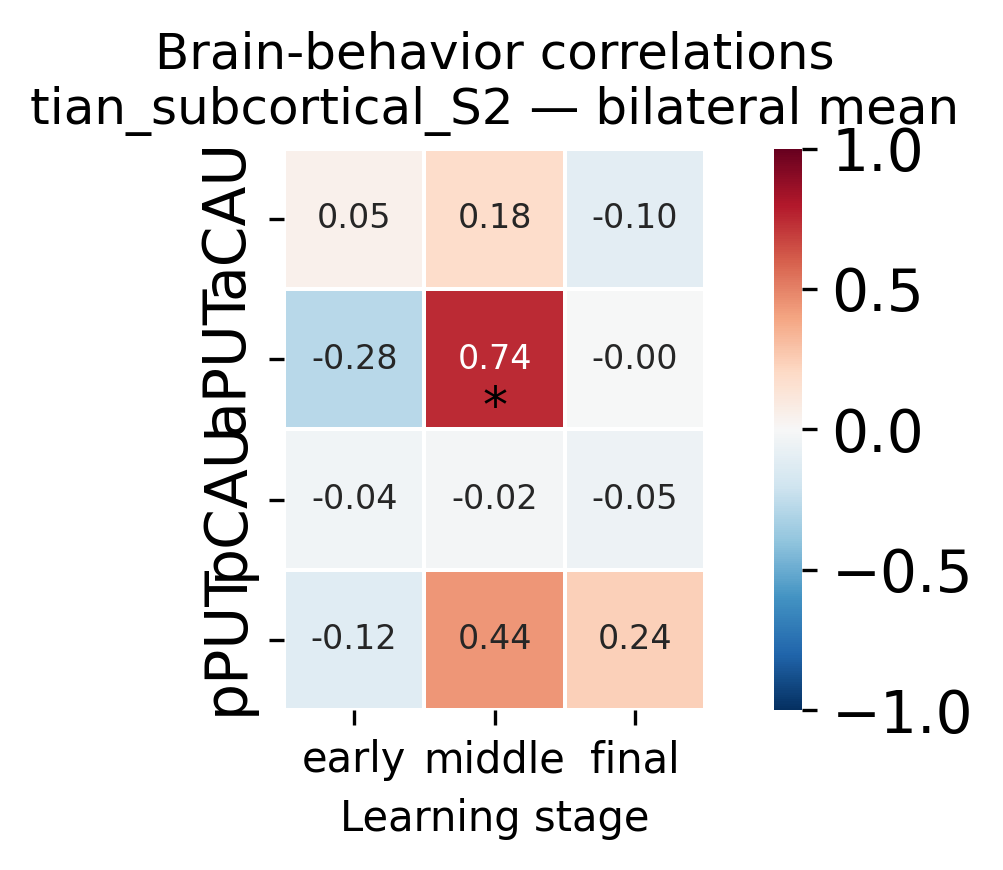

In [71]:
# pivot to ROI × stage matrix
r_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='r')[['early', 'middle', 'final']]
p_matrix = behav_corr_df.pivot(index='roi', columns='learning_stage', values='p')[['early', 'middle', 'final']]

fig, ax = plt.subplots(figsize=(5, len(r_matrix) * 0.5 + 1), dpi=300)
sns.heatmap(r_matrix, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size': 8},
            square=True)

# mark significant cells with an asterisk
for i, roi in enumerate(r_matrix.index):
    for j, stage in enumerate(['early', 'middle', 'final']):
        p = p_matrix.loc[roi, stage]
        if p < 0.05:
            ax.text(j + 0.5, i + 0.85, '*', ha='center', va='center',
                    fontsize=12, color='black')

ax.set_title(f'Brain-behavior correlations\n{network_name} — bilateral mean')
ax.set_ylabel('')
ax.set_xlabel('Learning stage')
plt.tight_layout()

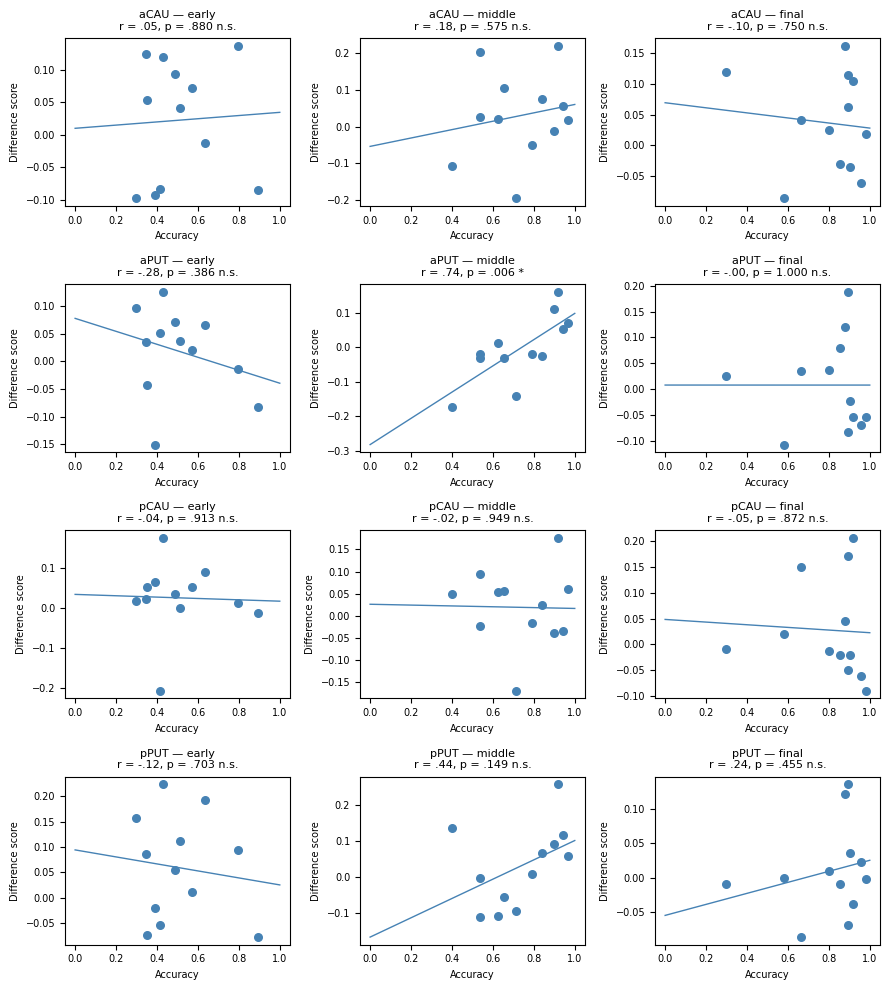

In [82]:
rois = behav_corr_df['roi'].unique()
stages = ['early', 'middle', 'final']

fig, axes = plt.subplots(len(rois), 3, figsize=(9, len(rois) * 2.5), dpi=100, 
                         sharex=False, sharey=False)

for ri, roi in enumerate(rois):
    for si, stage in enumerate(stages):
        ax = axes[ri, si]
        sub_df = roi_behav_df[(roi_behav_df['ROI'] == roi) & 
                              (roi_behav_df['learning_stage'] == stage)]
        
        ax.scatter(sub_df['accuracy'], sub_df['difference_score'], 
                   s=30, color='steelblue', zorder=3,
                   )
        
        # regression line
        m, b = np.polyfit(sub_df['accuracy'], sub_df['difference_score'], 1)
        #x_range = np.linspace(sub_df['accuracy'].min(), sub_df['accuracy'].max(), 100)
        x_range = np.linspace(0, 1, 100)
        ax.plot(x_range, m * x_range + b, color='steelblue', linewidth=1)
        
        # stat annotation
        row = behav_corr_df[(behav_corr_df['roi'] == roi) & 
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        ax.set_title(f"{roi} — {stage}\n{row['stat_str']} {p_str}", fontsize=8)
        ax.set_xlabel('Accuracy', fontsize=7)
        ax.set_ylabel('Difference score', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()


aCAU early: r = .05, p = .880 n.s.
aCAU middle: r = .18, p = .575 n.s.
aCAU final: r = -.10, p = .750 n.s.
aPUT early: r = -.28, p = .386 n.s.
aPUT middle: r = .74, p = .006 *
aPUT final: r = -.00, p = 1.000 n.s.
pCAU early: r = -.04, p = .913 n.s.
pCAU middle: r = -.02, p = .949 n.s.
pCAU final: r = -.05, p = .872 n.s.
pPUT early: r = -.12, p = .703 n.s.
pPUT middle: r = .44, p = .149 n.s.
pPUT final: r = .24, p = .455 n.s.


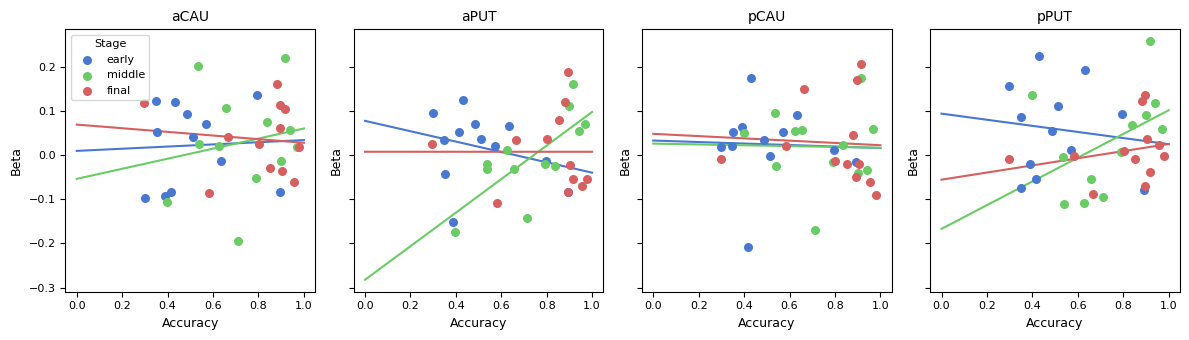

In [80]:
stage_colors = {'early': '#4878CF', 'middle': '#6ACC65', 'final': '#D65F5F'}
stages = ['early', 'middle', 'final']
rois = behav_corr_df['roi'].unique()

fig, axes = plt.subplots(1, len(rois), figsize=(3 * len(rois), 3.5), dpi=100, sharey=True)
if len(rois) == 1:
    axes = [axes]

for ri, roi in enumerate(rois):
    ax = axes[ri]
    for stage in stages:
        color = stage_colors[stage]
        sub_df = roi_behav_df[(roi_behav_df['ROI'] == roi) &
                              (roi_behav_df['learning_stage'] == stage)]

        ax.scatter(sub_df['accuracy'], sub_df['difference_score'], s=30,
                   color=color, label=stage, zorder=3)

        m, b = np.polyfit(sub_df['accuracy'], sub_df['difference_score'], 1)
        x_range = np.linspace(0, 1, 100)
        ax.plot(x_range, m * x_range + b, color=color, linewidth=1.5)

        # stat annotation per stage
        row = behav_corr_df[(behav_corr_df['roi'] == roi) &
                            (behav_corr_df['learning_stage'] == stage)].iloc[0]
        p_str = '*' if row['p'] < 0.05 else 'n.s.'
        print(f"{roi} {stage}: {row['stat_str']} {p_str}")

    ax.set_title(roi, fontsize=10)
    ax.set_xlabel('Accuracy', fontsize=9)
    ax.set_ylabel('Beta', fontsize=9)
    ax.tick_params(labelsize=8)

axes[0].legend(title='Stage', fontsize=8, title_fontsize=8)
plt.tight_layout()


## difference statistics and plots

In [42]:
# First, find the difference between models in the main dataframe
pairwise_models = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['model', ],
                             subject='participant_id',
                             padjust='fdr',
                             return_desc=True) 

# Check available columns
print("Available columns:", pairwise_models.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_models

# show results
pairwise_interaction[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'A', 'B', 'mean(A)', 'std(A)', 'mean(B)', 'std(B)',
       'Paired', 'Parametric', 'T', 'dof', 'alternative', 'p-unc', 'BF10',
       'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,BF10
0,model,model,Talker RDM,Tone RDM,-3.4436,11.0000,0.0055,9.661


In [43]:
pairwise_models

,Contrast,A,B,mean(A),std(A),mean(B),std(B),Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,model,Talker RDM,Tone RDM,-0.0153,0.0210,0.0082,0.0218,True,True,-3.4436,11.0000,two-sided,0.0055,9.661,-1.0591


In [44]:
# Check whether the statistics are different when only including dorsal striatum
# (no nucleus accumbens/ventral striatum)
pairwise_models = pg.pairwise_tests(data=dorsal_df,
                             dv='similarity', 
                             within=['model', ],
                             subject='participant_id',
                             padjust='fdr',
                             return_desc=True) 

# Check available columns
print("Available columns:", pairwise_models.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_models

# show results
pairwise_interaction[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'A', 'B', 'mean(A)', 'std(A)', 'mean(B)', 'std(B)',
       'Paired', 'Parametric', 'T', 'dof', 'alternative', 'p-unc', 'BF10',
       'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,BF10
0,model,model,Talker RDM,Tone RDM,-3.4436,11.0000,0.0055,9.661


In [45]:
pairwise_models

,Contrast,A,B,mean(A),std(A),mean(B),std(B),Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,model,Talker RDM,Tone RDM,-0.0153,0.0210,0.0082,0.0218,True,True,-3.4436,11.0000,two-sided,0.0055,9.661,-1.0591


#### ANOVA for factor significance

In [46]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(difference_df, 
              aggregate_func='mean',
              depvar='difference_score', 
              subject='participant_id', 
              within=['learning_stage','ROI', 'hemisphere']).fit()

# Display results
aov.summary()

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


,F Value,Num DF,Den DF,Pr > F
learning_stage,0.0816,2.0000,22.0000,0.9219
ROI,0.8430,3.0000,33.0000,0.4802
hemisphere,0.0285,1.0000,11.0000,0.8689
learning_stage:ROI,0.4558,6.0000,66.0000,0.8384
learning_stage:hemisphere,1.0397,2.0000,22.0000,0.3703
ROI:hemisphere,0.3699,3.0000,33.0000,0.7752
learning_stage:ROI:hemisphere,0.9232,6.0000,66.0000,0.4842


In [47]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(difference_df, 
              aggregate_func='mean',
              depvar='difference_score', 
              subject='participant_id', 
              within=['learning_stage','Axis', 'hemisphere']).fit()

# Display results
aov.summary()

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/stats/anova.py:508: FutureWarning: The provided callable <function mean at 0x7fe1ec57f280> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  self.data = (self.data
/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


,F Value,Num DF,Den DF,Pr > F
learning_stage,0.0816,2.0000,22.0000,0.9219
Axis,0.7336,1.0000,11.0000,0.4100
hemisphere,0.0285,1.0000,11.0000,0.8689
learning_stage:Axis,0.3692,2.0000,22.0000,0.6955
learning_stage:hemisphere,1.0397,2.0000,22.0000,0.3703
Axis:hemisphere,1.4079,1.0000,11.0000,0.2604
learning_stage:Axis:hemisphere,0.3453,2.0000,22.0000,0.7118


In [48]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(difference_df, 
              aggregate_func='mean',
              depvar='difference_score', 
              subject='participant_id', 
              within=['learning_stage','ROI_hemi']).fit()

# Display results
aov.summary()

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


,F Value,Num DF,Den DF,Pr > F
learning_stage,0.0816,2.0000,22.0000,0.9219
ROI_hemi,0.5992,7.0000,77.0000,0.7547
learning_stage:ROI_hemi,0.6666,14.0000,154.0000,0.8040


In [44]:

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=difference_df,
                             dv='difference_score', 
                             within=['ROI'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage#[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()

# show results
pairwise_interaction[['Contrast', 'Contrast', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof', 'alternative',
       'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,Contrast,A,B,T,dof,p-unc,p-corr,BF10
0,ROI,ROI,aCAU,aPUT,1.7242,11.0000,0.1126,0.5882,0.907
1,ROI,ROI,aCAU,pCAU,0.4396,11.0000,0.6688,0.8229,0.312
2,ROI,ROI,aCAU,pPUT,-0.1770,11.0000,0.8627,0.8627,0.291
3,ROI,ROI,aPUT,pCAU,-0.9407,11.0000,0.3670,0.7341,0.417
4,ROI,ROI,aPUT,pPUT,-1.3764,11.0000,0.1961,0.5882,0.617
5,ROI,ROI,pCAU,pPUT,-0.4156,11.0000,0.6857,0.8229,0.31


#### collapsed t-tests for significance vs. 0

In [42]:
model_sig_df = dorsal_df.groupby(["participant_id", "model"], 
                                       as_index=False).agg({"similarity": "mean"})

# Collect results
results = []

for model, data in model_sig_df.groupby("model"):
    t_stat, p_val = ttest_1samp(data["similarity"], 0)
    results.append({
        "model": model,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df


,model,t_stat,p_val,p_val_fdr
0,Talker RDM,-2.5274,0.0281,0.0562
1,Tone RDM,1.2971,0.2211,0.2211


In [49]:
# select model

model_df_collapsed = difference_df.groupby(["participant_id", "ROI"], 
                                       as_index=False).agg({"difference_score": "mean"})


In [63]:
# Collect results
results = []

for region, data in model_df_collapsed.groupby("ROI"):
    t_stat, p_val = ttest_1samp(data["difference_score"], 0)
    results.append({
        "ROI": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,ROI,t_stat,p_val,p_val_fdr
0,aCAU,2.7271,0.0197,0.0787
1,aPUT,1.6963,0.1179,0.1527
2,pCAU,1.5363,0.1527,0.1527
3,pPUT,2.0549,0.0644,0.1289


In [62]:
mean_df = model_df_collapsed.groupby('ROI',as_index=False).agg({"difference_score": "mean"})
mean_df

,ROI,difference_score
0,aCAU,0.0296
1,aPUT,0.0076
2,pCAU,0.0239
3,pPUT,0.0329


In [66]:
merged_df = pd.merge(results_df, mean_df, on='ROI')

merged_df

,ROI,t_stat,p_val,p_val_fdr,difference_score
0,aCAU,2.7271,0.0197,0.0787,0.0296
1,aPUT,1.6963,0.1179,0.1527,0.0076
2,pCAU,1.5363,0.1527,0.1527,0.0239
3,pPUT,2.0549,0.0644,0.1289,0.0329


In [54]:

roi_df_collapsed = difference_df.groupby(["participant_id", "ROI", 'learning_stage'], 
                                       as_index=False).agg({"difference_score": "mean"})

# Collect results
results = []

for region, data in roi_df_collapsed.groupby("ROI"):
    t_stat, p_val = ttest_rel(data[data.learning_stage=='final']['difference_score'], 
                              data[data.learning_stage=='early']['difference_score'])
    results.append({
        "region": region,
        "t_stat": t_stat,
        "p_val": p_val
    })

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Apply FDR correction
results_df["p_val_fdr"] = multipletests(results_df["p_val"], method="fdr_bh")[1]

# Print or export the table
results_df

# Optional: export
# results_df.to_csv("roi_stats.csv", index=False)
# results_df.to_excel("roi_stats.xlsx", index=False)


,region,t_stat,p_val,p_val_fdr
0,aCAU,0.3496,0.7333,0.9446
1,aPUT,-0.2384,0.8160,0.9446
2,pCAU,0.0711,0.9446,0.9446
3,pPUT,-1.5582,0.1475,0.5899


#### plots

/scratch/slurm-7026153/ipykernel_368845/1702021460.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


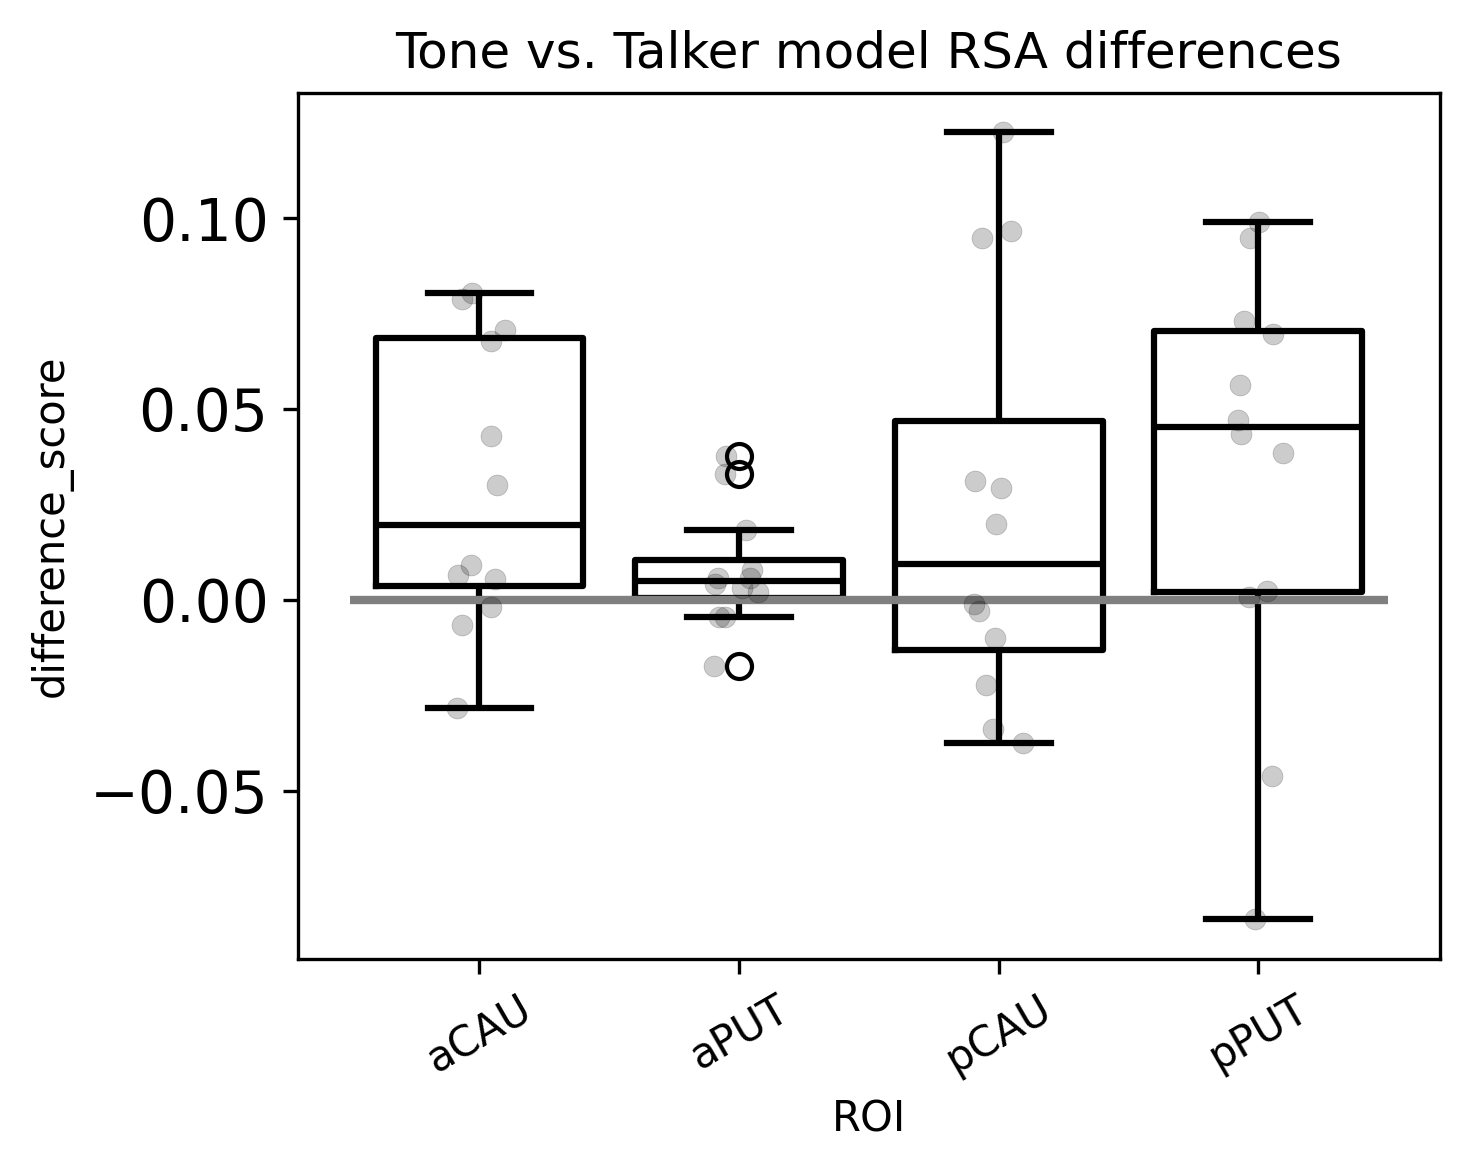

In [55]:
# Plot model differences rather than individual model scores
roi_df_collapsed = difference_df.groupby(["participant_id", "ROI"], 
                                       as_index=False).agg({"difference_score": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(5,4), dpi=300)

sns.boxplot(data=roi_df_collapsed, 
              x='ROI', y='difference_score', 
              color='k',
              #hue='model', palette='flare',
              #fliersize = 0,            
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='ROI', y='difference_score', 
              color='k',
              #hue='model', palette='flare', dodge=True,
              linewidth=0.2,
              alpha=.2,
              #legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='-', linewidth=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Tone vs. Talker model RSA differences');
#ax.set_ylim([-5, 5])

fig.tight_layout()


/scratch/slurm-6985174/ipykernel_497943/1937843720.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')


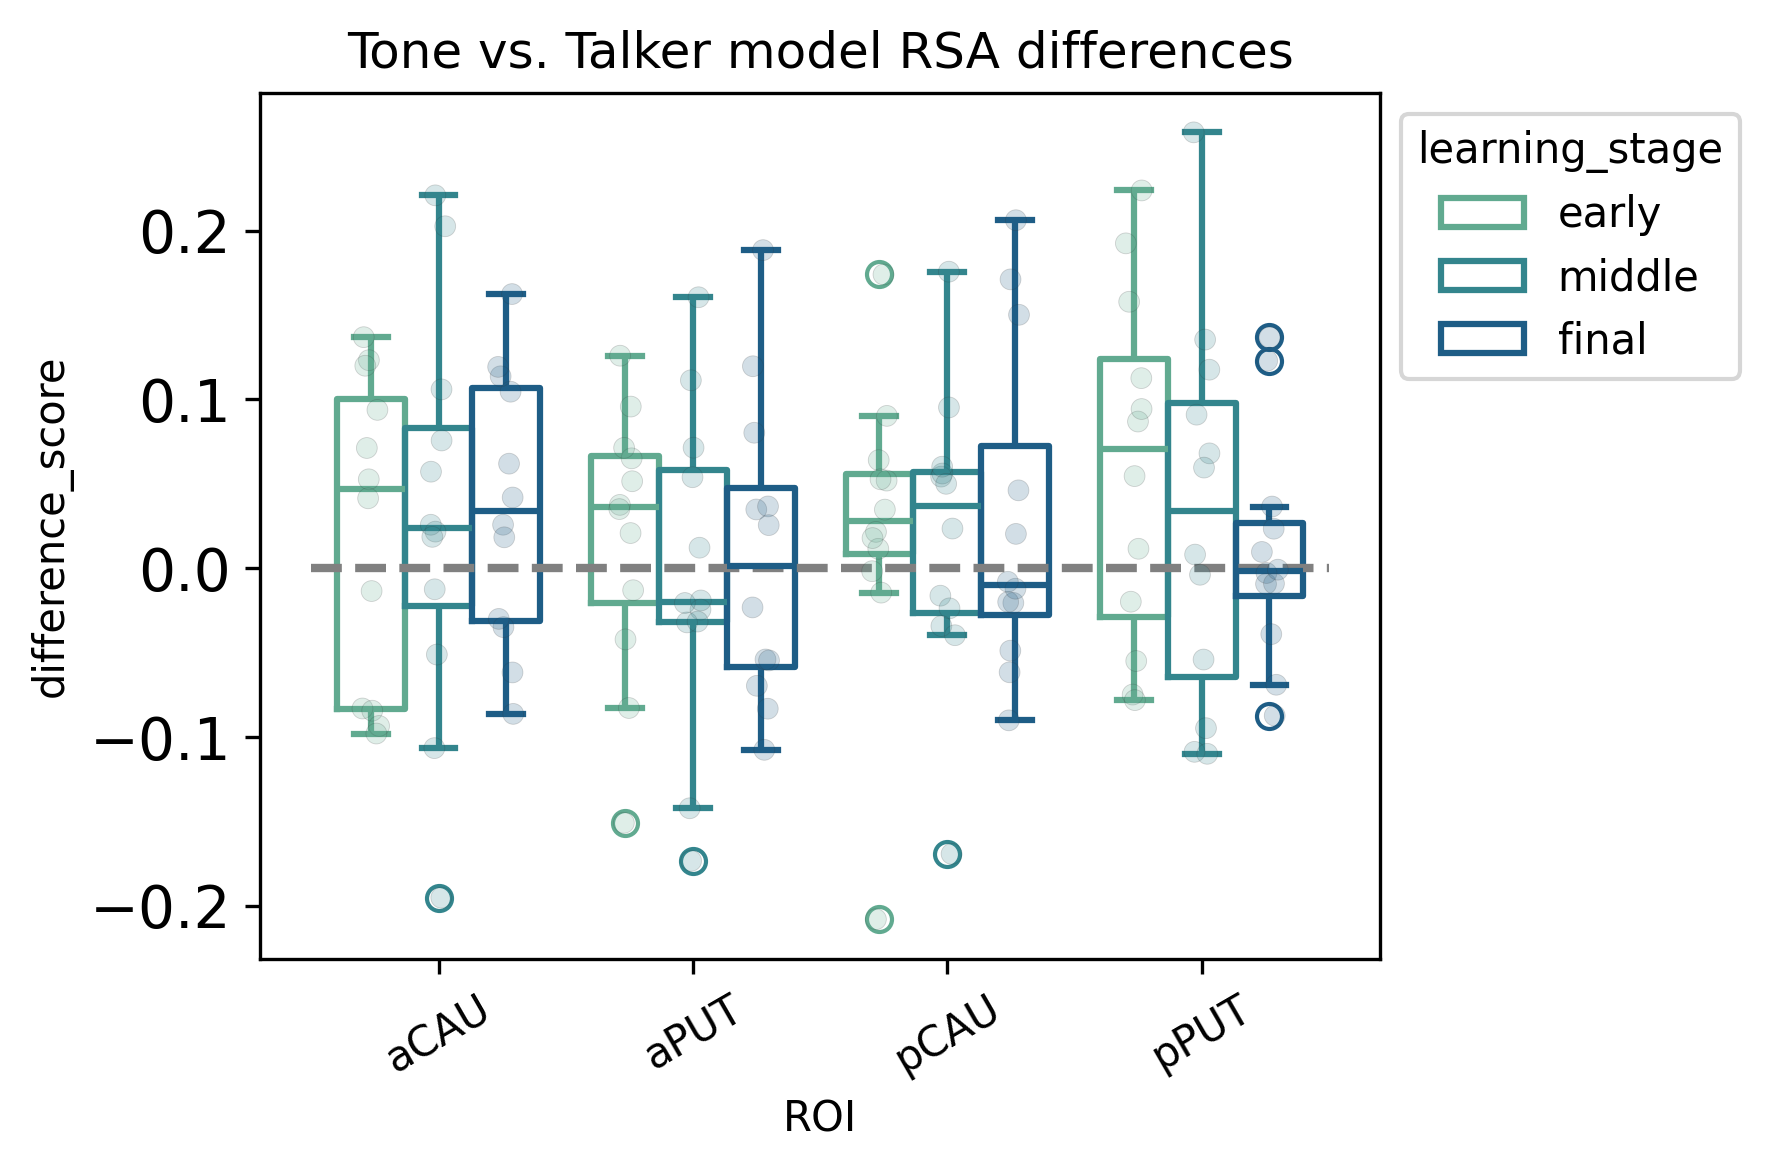

In [65]:
# Plot model differences rather than individual model scores
roi_df_collapsed = difference_df.groupby(["participant_id", "ROI", 'learning_stage'], 
                                       as_index=False).agg({"difference_score": "mean"})

fig, ax = plt.subplots(1, 1, figsize=(6,4), dpi=300)

sns.boxplot(data=roi_df_collapsed, 
              x='ROI', y='difference_score', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              palette='crest',  
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax);
sns.stripplot(data=roi_df_collapsed, 
              x='ROI', y='difference_score', 
              hue='learning_stage', hue_order=['early', 'middle', 'final'],
              palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax);


xmin, xmax = ax.get_xlim()
ax.hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(f'Tone vs. Talker model RSA differences');
#ax.set_ylim([-5, 5])

fig.tight_layout()


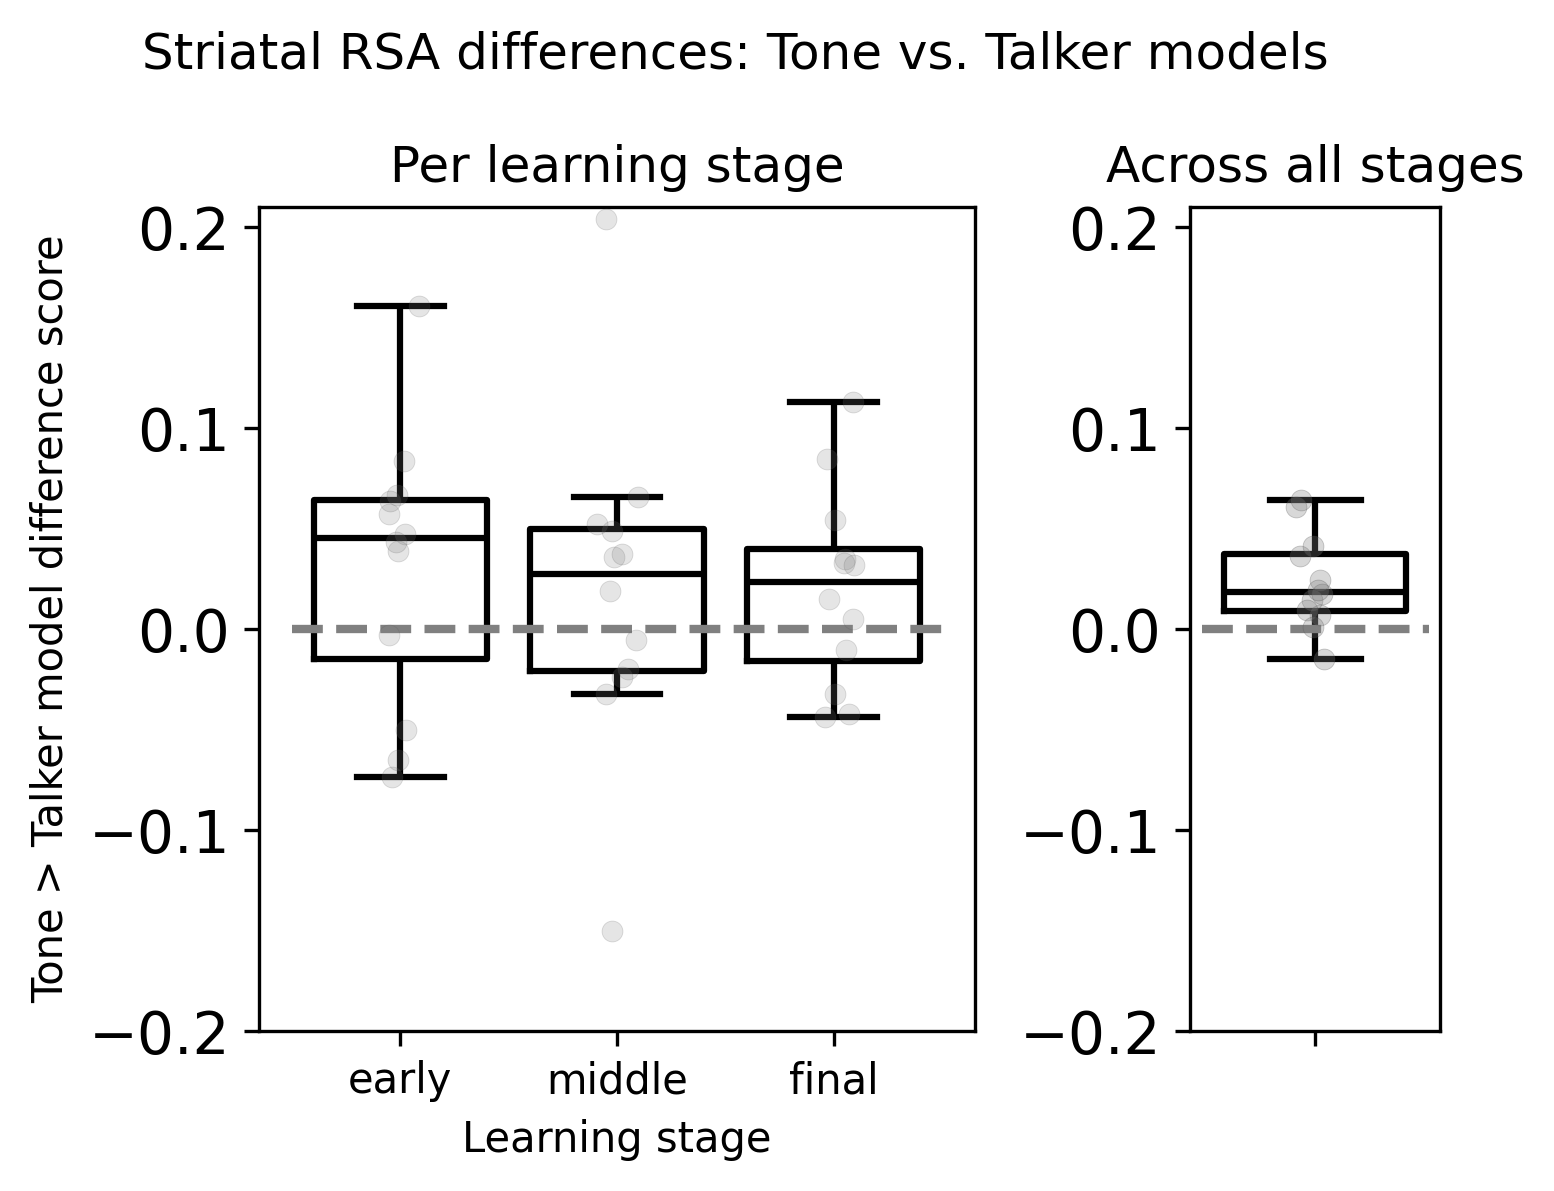

In [56]:
# Plot model differences rather than individual model scores
roi_df_collapsed = difference_df.groupby(["participant_id", 'learning_stage'], 
                                       as_index=False).agg({"difference_score": "mean"})

#fig, ax = plt.subplots(1, 1, figsize=(4,4), dpi=300)
fig, ax_dict = plt.subplot_mosaic("AAB", figsize=(5,4), dpi=300)

fig.suptitle(f'Striatal RSA differences: Tone vs. Talker models')

sns.boxplot(data=roi_df_collapsed, 
              y='difference_score', 
              x='learning_stage', order=['early', 'middle', 'final'],
              color='Black', #palette='crest',  
              fliersize=0,
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax_dict['A']);
sns.stripplot(data=roi_df_collapsed, 
              y='difference_score', 
              x='learning_stage', order=['early', 'middle', 'final'],
              color='Grey', #palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax_dict['A']);

xmin, xmax = ax_dict['A'].get_xlim()
ax_dict['A'].set_xlabel('Learning stage')
ax_dict['A'].set_ylabel('Tone > Talker model difference score')
ax_dict['A'].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=2)
#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax_dict['A'].set_title('Per learning stage');
ax_dict['A'].set_ylim([-0.2, 0.21])

all_collapsed = difference_df.groupby(["participant_id"], 
                                       as_index=False).agg({"difference_score": "mean"})
sns.boxplot(data=all_collapsed, 
              y='difference_score', 
              color='Black', #palette='crest',  
              fliersize=0,
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax_dict['B']);
sns.stripplot(data=all_collapsed, 
              y='difference_score', 
              color='Grey', #palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.3,
              legend=None,
              ax=ax_dict['B']);

xmin, xmax = ax_dict['B'].get_xlim()
ax_dict['B'].set_ylabel('')
ax_dict['B'].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=2)
#ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='center')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax_dict['B'].set_title(f'Across all stages');
ax_dict['B'].set_ylim([-0.2, 0.21])


fig.tight_layout()
fig.show()


/scratch/slurm-6985174/ipykernel_497943/3020951224.py:33: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_dict['A'].set_xticklabels(ax_dict['A'].get_xticklabels(), rotation=30, ha='center')
/scratch/slurm-6985174/ipykernel_497943/3020951224.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_dict['B'].set_xticklabels(ax_dict['B'].get_xticklabels(), rotation=30, ha='center')


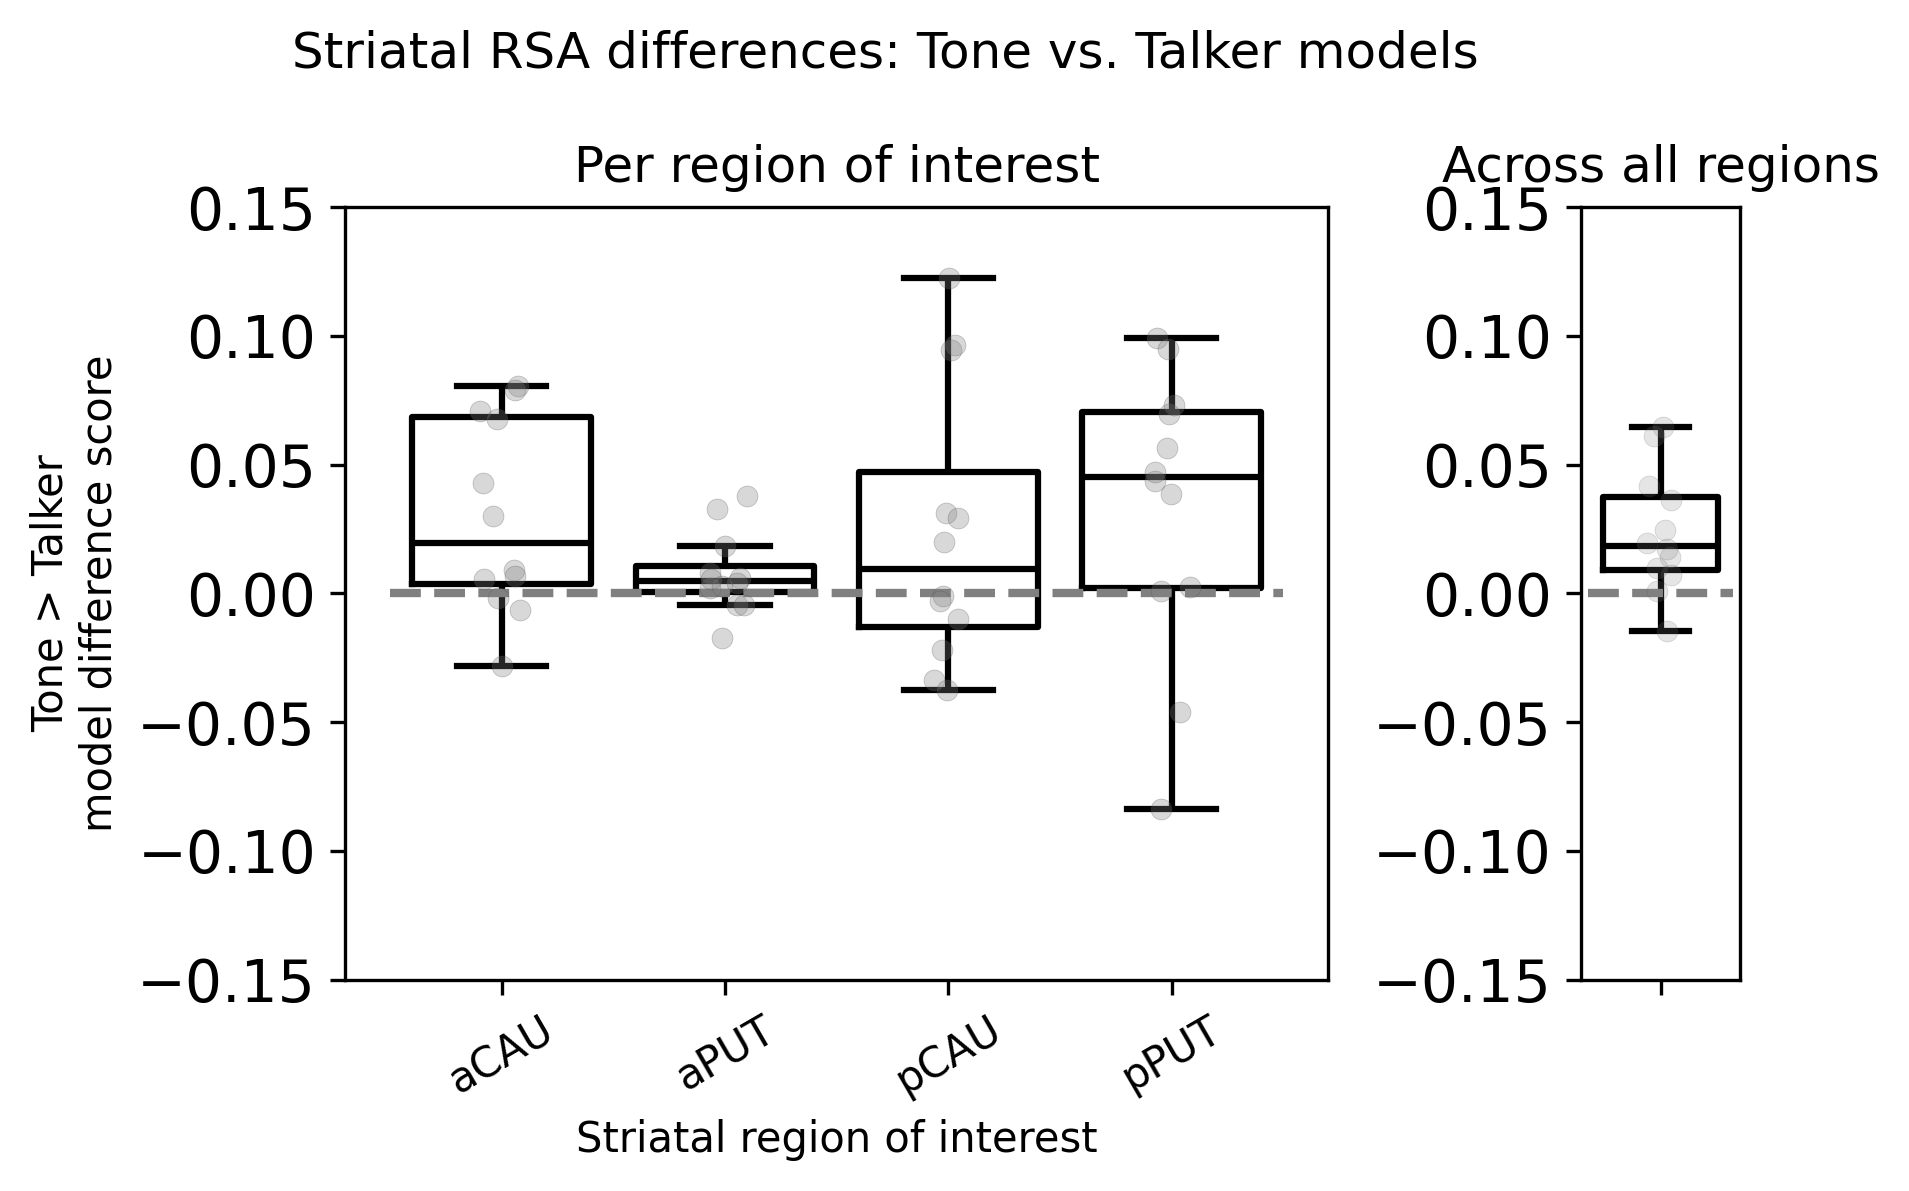

In [68]:
# Plot model differences rather than individual model scores
roi_df_collapsed = difference_df.groupby(["participant_id", 'ROI'], 
                                       as_index=False).agg({"difference_score": "mean"})

#fig, ax = plt.subplots(1, 1, figsize=(4,4), dpi=300)
fig, ax_dict = plt.subplot_mosaic("AAAB", figsize=(6,4), dpi=300)

fig.suptitle(f'Striatal RSA differences: Tone vs. Talker models')

sns.boxplot(data=roi_df_collapsed, 
              y='difference_score', 
              x='ROI', 
              color='Black', #palette='crest',  
              fliersize=0,
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax_dict['A']);
sns.stripplot(data=roi_df_collapsed, 
              y='difference_score', 
              x='ROI', 
              color='Grey', #palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.3,
              legend=None,
              ax=ax_dict['A']);

xmin, xmax = ax_dict['A'].get_xlim()
ax_dict['A'].set_xlabel('Striatal region of interest')
ax_dict['A'].set_ylabel('Tone > Talker\nmodel difference score')
ax_dict['A'].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=2)
ax_dict['A'].set_xticklabels(ax_dict['A'].get_xticklabels(), rotation=30, ha='center')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax_dict['A'].set_title('Per region of interest');
ax_dict['A'].set_ylim([-0.15, 0.15])

all_collapsed = difference_df.groupby(["participant_id"], 
                                       as_index=False).agg({"difference_score": "mean"})
sns.boxplot(data=all_collapsed, 
              y='difference_score', 
              color='Black', #palette='crest',  
              fliersize=0,
              linewidth=1.5,
              fill=False,
              #legend=None,
              ax=ax_dict['B']);
sns.stripplot(data=all_collapsed, 
              y='difference_score', 
              color='Grey', #palette='crest',
              dodge=True,
              linewidth=0.2,
              alpha=.2,
              legend=None,
              ax=ax_dict['B']);


xmin, xmax = ax_dict['B'].get_xlim()
ax_dict['B'].set_ylabel('')
ax_dict['B'].hlines(y=0, xmin=xmin, xmax=xmax, color='0.5', linestyle='--', linewidth=2)
ax_dict['B'].set_xticklabels(ax_dict['B'].get_xticklabels(), rotation=30, ha='center')
#sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax_dict['B'].set_title(f'Across all regions');
ax_dict['B'].set_ylim([-0.15, 0.15])


fig.tight_layout()
fig.show()


## statistics

In [34]:
from scipy import stats

#### ANOVA stats – hemisphere-specific ROIs

In [35]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

In [36]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(rostcaud_df, 
              aggregate_func='mean',
              depvar='similarity', 
              subject='participant_id', 
              within=['learning_stage','ROI_hemi', 'model']).fit()

# Display results
print(aov)

                            Anova
                              F Value  Num DF  Den DF  Pr > F
-------------------------------------------------------------
learning_stage                 0.1054  1.0000  11.0000 0.7516
ROI_hemi                       1.4039 11.0000 121.0000 0.1796
model                          8.6138  1.0000  11.0000 0.0136
learning_stage:ROI_hemi        2.6364 11.0000 121.0000 0.0047
learning_stage:model           0.2987  1.0000  11.0000 0.5956
ROI_hemi:model                 0.4364 11.0000 121.0000 0.9368
learning_stage:ROI_hemi:model  1.0526 11.0000 121.0000 0.4054



/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [37]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['learning_stage', 'ROI_hemi'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'learning_stage', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,learning_stage,A,B,T,dof,p-unc,p-corr,BF10
0,learning_stage * ROI_hemi,early,NAc-core-rh,aPUT-lh,2.556948,11.0,0.026663,0.365706,2.701
1,learning_stage * ROI_hemi,early,NAc-core-rh,pPUT-rh,2.346537,11.0,0.038723,0.365706,2.018
2,learning_stage * ROI_hemi,early,NAc-shell-rh,pCAU-lh,2.224812,11.0,0.047960,0.365706,1.712
3,learning_stage * ROI_hemi,early,NAc-shell-rh,pPUT-rh,2.636251,11.0,0.023148,0.365706,3.019
4,learning_stage * ROI_hemi,early,aCAU-rh,pCAU-lh,2.302791,11.0,0.041826,0.365706,1.902
5,learning_stage * ROI_hemi,early,pCAU-lh,pCAU-rh,-3.392178,11.0,0.006012,0.365706,8.966
6,learning_stage * ROI_hemi,early,pCAU-rh,pPUT-rh,2.202487,11.0,0.049869,0.365706,1.662
7,learning_stage * ROI_hemi,final,NAc-core-rh,NAc-shell-rh,2.267982,11.0,0.044465,0.365706,1.814
8,learning_stage * ROI_hemi,final,NAc-shell-lh,NAc-shell-rh,2.402673,11.0,0.035066,0.365706,2.18
9,learning_stage * ROI_hemi,final,NAc-shell-rh,aPUT-lh,-2.584748,11.0,0.025375,0.365706,2.808


In [38]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['ROI_hemi', 'learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise_interaction[['Contrast', 'ROI_hemi', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'ROI_hemi', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,ROI_hemi,A,B,T,dof,p-unc,p-corr,BF10
0,ROI_hemi * learning_stage,NAc-shell-rh,early,final,2.885392,11.0,0.014828,0.088965,4.306
1,ROI_hemi * learning_stage,pCAU-lh,early,final,-4.768602,11.0,0.000582,0.006984,63.441


In [39]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['ROI_hemi', 'model', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise_interaction[['Contrast', 'ROI_hemi', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'ROI_hemi', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,ROI_hemi,A,B,T,dof,p-unc,p-corr,BF10
0,ROI_hemi * model,NAc-core-lh,Talker RDM,Tone RDM,-0.150918,11.0,0.882773,0.882773,0.29
1,ROI_hemi * model,NAc-core-rh,Talker RDM,Tone RDM,-1.403787,11.0,0.187979,0.368468,0.634
2,ROI_hemi * model,NAc-shell-lh,Talker RDM,Tone RDM,-0.955103,11.0,0.360044,0.432053,0.421
3,ROI_hemi * model,NAc-shell-rh,Talker RDM,Tone RDM,-1.037156,11.0,0.321925,0.429234,0.45
4,ROI_hemi * model,aCAU-lh,Talker RDM,Tone RDM,-1.886419,11.0,0.085901,0.343602,1.105
5,ROI_hemi * model,aCAU-rh,Talker RDM,Tone RDM,-1.397857,11.0,0.189706,0.368468,0.631
6,ROI_hemi * model,aPUT-lh,Talker RDM,Tone RDM,-1.423396,11.0,0.182361,0.368468,0.648
7,ROI_hemi * model,aPUT-rh,Talker RDM,Tone RDM,-0.366888,11.0,0.720662,0.786177,0.305
8,ROI_hemi * model,pCAU-lh,Talker RDM,Tone RDM,-1.950785,11.0,0.077015,0.343602,1.198
9,ROI_hemi * model,pCAU-rh,Talker RDM,Tone RDM,-1.226422,11.0,0.245645,0.368468,0.532


In [40]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp

In [41]:
# select model
model_id = 'Tone RDM'
print(model_id)
model_df = laterality_df[laterality_df['model']==model_id]
laterality_df_collapsed = model_df.groupby(["participant_id", "ROI_hemi"], 
                                       as_index=False).agg({"similarity": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in laterality_df_collapsed.groupby(["ROI_hemi"]):
    t_stat, p_val = ttest_1samp(data["similarity"], 0) # , df
    p_values.append(p_val)
    comparisons.append((region, t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t-stat: {t_stat:.2f} -> Corrected p={p_val_corr:.4f}")


Tone RDM
Region: ('NAc-core-lh',), t-stat: -0.70 -> Corrected p=0.9305
Region: ('NAc-core-rh',), t-stat: 0.79 -> Corrected p=0.9305
Region: ('NAc-shell-lh',), t-stat: 0.08 -> Corrected p=0.9367
Region: ('NAc-shell-rh',), t-stat: -0.35 -> Corrected p=0.9305
Region: ('aCAU-lh',), t-stat: 1.33 -> Corrected p=0.9305
Region: ('aCAU-rh',), t-stat: 0.78 -> Corrected p=0.9305
Region: ('aPUT-lh',), t-stat: -0.12 -> Corrected p=0.9367
Region: ('aPUT-rh',), t-stat: -0.52 -> Corrected p=0.9305
Region: ('pCAU-lh',), t-stat: 1.30 -> Corrected p=0.9305
Region: ('pCAU-rh',), t-stat: 1.16 -> Corrected p=0.9305
Region: ('pPUT-lh',), t-stat: -0.34 -> Corrected p=0.9305
Region: ('pPUT-rh',), t-stat: -0.29 -> Corrected p=0.9305


In [42]:
# select model
model_id = 'Talker RDM'
print(model_id)
model_df = laterality_df[laterality_df['model']==model_id]
laterality_df_collapsed = model_df.groupby(["participant_id", "ROI_hemi"], 
                                       as_index=False).agg({"similarity": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in laterality_df_collapsed.groupby(["ROI_hemi"]):
    t_stat, p_val = ttest_1samp(data["similarity"], 0) # , df
    p_values.append(p_val)
    comparisons.append((region, t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t-stat: {t_stat:.2f} -> Corrected p={p_val_corr:.4f}")


Talker RDM
Region: ('NAc-core-lh',), t-stat: -0.76 -> Corrected p=0.5076
Region: ('NAc-core-rh',), t-stat: -1.14 -> Corrected p=0.3649
Region: ('NAc-shell-lh',), t-stat: -1.13 -> Corrected p=0.3649
Region: ('NAc-shell-rh',), t-stat: -1.59 -> Corrected p=0.3539
Region: ('aCAU-lh',), t-stat: -1.40 -> Corrected p=0.3539
Region: ('aCAU-rh',), t-stat: -1.08 -> Corrected p=0.3649
Region: ('aPUT-lh',), t-stat: -2.07 -> Corrected p=0.2527
Region: ('aPUT-rh',), t-stat: -1.54 -> Corrected p=0.3539
Region: ('pCAU-lh',), t-stat: -1.34 -> Corrected p=0.3539
Region: ('pCAU-rh',), t-stat: -0.58 -> Corrected p=0.5704
Region: ('pPUT-lh',), t-stat: -2.92 -> Corrected p=0.0830
Region: ('pPUT-rh',), t-stat: -4.13 -> Corrected p=0.0200


#### ANOVA stats – ROI x hemisphere

In [43]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.anova import AnovaRM

In [44]:
# Mixed-Effects ANOVA with Hemisphere, Region, and Interaction
aov = AnovaRM(rostcaud_df, 
              aggregate_func='mean',
              depvar='similarity', 
              subject='participant_id', 
              within=['hemisphere', 'learning_stage','ROI', 'model']).fit()

# Display results
print(aov)

                              Anova
                                    F Value Num DF  Den DF Pr > F
-----------------------------------------------------------------
hemisphere                           0.0002 1.0000 11.0000 0.9882
learning_stage                       0.1054 1.0000 11.0000 0.7516
ROI                                  1.8627 5.0000 55.0000 0.1159
model                                8.6138 1.0000 11.0000 0.0136
hemisphere:learning_stage            5.5160 1.0000 11.0000 0.0386
hemisphere:ROI                       0.7395 5.0000 55.0000 0.5971
learning_stage:ROI                   2.5417 5.0000 55.0000 0.0386
hemisphere:model                     0.0597 1.0000 11.0000 0.8114
learning_stage:model                 0.2987 1.0000 11.0000 0.5956
ROI:model                            0.4680 5.0000 55.0000 0.7984
hemisphere:learning_stage:ROI        2.0568 5.0000 55.0000 0.0849
hemisphere:learning_stage:model      0.0840 1.0000 11.0000 0.7774
hemisphere:ROI:model                 0.4

/ix1/bchandrasekaran/krs228/software/miniconda3/envs/py3/lib/python3.9/site-packages/statsmodels/iolib/summary2.py:579: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dat = dat.applymap(lambda x: _formatter(x, float_format))


In [45]:
import pingouin as pg

# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['learning_stage', 'ROI_hemi'],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise_interaction[['Contrast', 'learning_stage', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'learning_stage', 'A', 'B', 'Paired', 'Parametric', 'T',
       'dof', 'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,learning_stage,A,B,T,dof,p-unc,p-corr,BF10
0,learning_stage * ROI_hemi,early,NAc-core-rh,aPUT-lh,2.556948,11.0,0.026663,0.365706,2.701
1,learning_stage * ROI_hemi,early,NAc-core-rh,pPUT-rh,2.346537,11.0,0.038723,0.365706,2.018
2,learning_stage * ROI_hemi,early,NAc-shell-rh,pCAU-lh,2.224812,11.0,0.047960,0.365706,1.712
3,learning_stage * ROI_hemi,early,NAc-shell-rh,pPUT-rh,2.636251,11.0,0.023148,0.365706,3.019
4,learning_stage * ROI_hemi,early,aCAU-rh,pCAU-lh,2.302791,11.0,0.041826,0.365706,1.902
5,learning_stage * ROI_hemi,early,pCAU-lh,pCAU-rh,-3.392178,11.0,0.006012,0.365706,8.966
6,learning_stage * ROI_hemi,early,pCAU-rh,pPUT-rh,2.202487,11.0,0.049869,0.365706,1.662
7,learning_stage * ROI_hemi,final,NAc-core-rh,NAc-shell-rh,2.267982,11.0,0.044465,0.365706,1.814
8,learning_stage * ROI_hemi,final,NAc-shell-lh,NAc-shell-rh,2.402673,11.0,0.035066,0.365706,2.18
9,learning_stage * ROI_hemi,final,NAc-shell-rh,aPUT-lh,-2.584748,11.0,0.025375,0.365706,2.808


In [46]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['ROI_hemi', 'learning_stage', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise_interaction[['Contrast', 'ROI_hemi', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'ROI_hemi', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,ROI_hemi,A,B,T,dof,p-unc,p-corr,BF10
0,ROI_hemi * learning_stage,NAc-shell-rh,early,final,2.885392,11.0,0.014828,0.088965,4.306
1,ROI_hemi * learning_stage,pCAU-lh,early,final,-4.768602,11.0,0.000582,0.006984,63.441


In [47]:
# Pairwise comparisons for region with FDR correction
pairwise_by_learning_stage = pg.pairwise_tests(data=rostcaud_df,
                             dv='similarity', 
                             within=['ROI_hemi', 'model', ],
                             subject='participant_id',
                             padjust='fdr') 

# Check available columns
print("Available columns:", pairwise_by_learning_stage.columns)

# Display key columns 
print("\nPost-hoc Pairwise Comparisons:")

pd.set_option('display.max_rows', None)

pairwise_interaction = pairwise_by_learning_stage[pairwise_by_learning_stage.Contrast.str.contains(' * ')].reset_index()
#pairwise_interaction = pairwise_interaction[pairwise_interaction['p-unc'] < 0.05].reset_index()

# show results
pairwise_interaction[['Contrast', 'ROI_hemi', 'A', 'B', 'T', 'dof', 'p-unc', 'p-corr', 'BF10']]
#print(pairwise_interaction)

Available columns: Index(['Contrast', 'ROI_hemi', 'A', 'B', 'Paired', 'Parametric', 'T', 'dof',
       'alternative', 'p-unc', 'p-corr', 'p-adjust', 'BF10', 'hedges'],
      dtype='object')

Post-hoc Pairwise Comparisons:


,Contrast,ROI_hemi,A,B,T,dof,p-unc,p-corr,BF10
0,ROI_hemi * model,NAc-core-lh,Talker RDM,Tone RDM,-0.150918,11.0,0.882773,0.882773,0.29
1,ROI_hemi * model,NAc-core-rh,Talker RDM,Tone RDM,-1.403787,11.0,0.187979,0.368468,0.634
2,ROI_hemi * model,NAc-shell-lh,Talker RDM,Tone RDM,-0.955103,11.0,0.360044,0.432053,0.421
3,ROI_hemi * model,NAc-shell-rh,Talker RDM,Tone RDM,-1.037156,11.0,0.321925,0.429234,0.45
4,ROI_hemi * model,aCAU-lh,Talker RDM,Tone RDM,-1.886419,11.0,0.085901,0.343602,1.105
5,ROI_hemi * model,aCAU-rh,Talker RDM,Tone RDM,-1.397857,11.0,0.189706,0.368468,0.631
6,ROI_hemi * model,aPUT-lh,Talker RDM,Tone RDM,-1.423396,11.0,0.182361,0.368468,0.648
7,ROI_hemi * model,aPUT-rh,Talker RDM,Tone RDM,-0.366888,11.0,0.720662,0.786177,0.305
8,ROI_hemi * model,pCAU-lh,Talker RDM,Tone RDM,-1.950785,11.0,0.077015,0.343602,1.198
9,ROI_hemi * model,pCAU-rh,Talker RDM,Tone RDM,-1.226422,11.0,0.245645,0.368468,0.532


In [48]:
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_1samp

In [49]:
# select model
model_id = 'Tone RDM'
print(model_id)
model_df = laterality_df[laterality_df['model']==model_id]
laterality_df_collapsed = model_df.groupby(["participant_id", "ROI_hemi"], 
                                       as_index=False).agg({"similarity": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in laterality_df_collapsed.groupby(["ROI_hemi"]):
    t_stat, p_val = ttest_1samp(data["similarity"], 0) # , df
    p_values.append(p_val)
    comparisons.append((region, t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t-stat: {t_stat:.2f} -> Corrected p={p_val_corr:.4f}")


Tone RDM
Region: ('NAc-core-lh',), t-stat: -0.70 -> Corrected p=0.9305
Region: ('NAc-core-rh',), t-stat: 0.79 -> Corrected p=0.9305
Region: ('NAc-shell-lh',), t-stat: 0.08 -> Corrected p=0.9367
Region: ('NAc-shell-rh',), t-stat: -0.35 -> Corrected p=0.9305
Region: ('aCAU-lh',), t-stat: 1.33 -> Corrected p=0.9305
Region: ('aCAU-rh',), t-stat: 0.78 -> Corrected p=0.9305
Region: ('aPUT-lh',), t-stat: -0.12 -> Corrected p=0.9367
Region: ('aPUT-rh',), t-stat: -0.52 -> Corrected p=0.9305
Region: ('pCAU-lh',), t-stat: 1.30 -> Corrected p=0.9305
Region: ('pCAU-rh',), t-stat: 1.16 -> Corrected p=0.9305
Region: ('pPUT-lh',), t-stat: -0.34 -> Corrected p=0.9305
Region: ('pPUT-rh',), t-stat: -0.29 -> Corrected p=0.9305


In [50]:
# select model
model_id = 'Talker RDM'
print(model_id)
model_df = laterality_df[laterality_df['model']==model_id]
laterality_df_collapsed = model_df.groupby(["participant_id", "ROI_hemi"], 
                                       as_index=False).agg({"similarity": "mean"})

# Collect p-values
p_values = []
t_stats = []
comparisons = []

for region, data in laterality_df_collapsed.groupby(["ROI_hemi"]):
    t_stat, p_val = ttest_1samp(data["similarity"], 0) # , df
    p_values.append(p_val)
    comparisons.append((region, t_stat))
    t_stats.append(t_stat)

# Apply FDR correction
_, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')

# Print corrected results
for (region, t_stat), p_val_corr in zip(comparisons, p_corrected):
    print(f"Region: {region}, t-stat: {t_stat:.2f} -> Corrected p={p_val_corr:.4f}")


Talker RDM
Region: ('NAc-core-lh',), t-stat: -0.76 -> Corrected p=0.5076
Region: ('NAc-core-rh',), t-stat: -1.14 -> Corrected p=0.3649
Region: ('NAc-shell-lh',), t-stat: -1.13 -> Corrected p=0.3649
Region: ('NAc-shell-rh',), t-stat: -1.59 -> Corrected p=0.3539
Region: ('aCAU-lh',), t-stat: -1.40 -> Corrected p=0.3539
Region: ('aCAU-rh',), t-stat: -1.08 -> Corrected p=0.3649
Region: ('aPUT-lh',), t-stat: -2.07 -> Corrected p=0.2527
Region: ('aPUT-rh',), t-stat: -1.54 -> Corrected p=0.3539
Region: ('pCAU-lh',), t-stat: -1.34 -> Corrected p=0.3539
Region: ('pCAU-rh',), t-stat: -0.58 -> Corrected p=0.5704
Region: ('pPUT-lh',), t-stat: -2.92 -> Corrected p=0.0830
Region: ('pPUT-rh',), t-stat: -4.13 -> Corrected p=0.0200
